In [1]:
# Import necessary libraries
import pandas as pd
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

Load and prepare the dataset

In [2]:
# load data
df = pd.read_csv("StudentsPerformance.xls")
df.columns = df.columns.str.replace(" ", "_")

# create a pass/fail label
df["avg_score"] = df[["math_score", "reading_score", "writing_score"]].mean(axis=1)
df["pass"] = (df["avg_score"] >= 50).astype(int)

# split features and target
X = df.drop(columns=["math_score", "reading_score", "writing_score", "avg_score", "pass"])
y = df["pass"]

# find categorical columns
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train model and check performance

In [3]:
# train a simple model
model = CatBoostClassifier(
    depth=5,
    learning_rate=0.1,
    iterations=200,
    verbose=0
)

model.fit(X_train, y_train, cat_features=cat_features)

# check performance
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train accuracy:", round(train_acc, 3))
print("Test accuracy:", round(test_acc, 3))

Train accuracy: 0.907
Test accuracy: 0.86


Explain the model (SHAP)

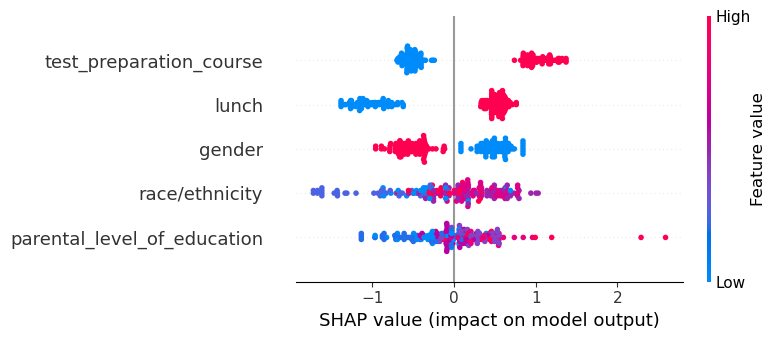

In [4]:
# --- Global explanation ---
# prepare data for SHAP coloring
X_test_shap = X_test.copy()

X_test_shap["test_preparation_course"] = X_test_shap["test_preparation_course"].map({
    "none": 0, "completed": 1
})

X_test_shap["lunch"] = X_test_shap["lunch"].map({
    "free/reduced": 0, "standard": 1
})

X_test_shap["gender"] = X_test_shap["gender"].map({
    "female": 0, "male": 1
})

# ordered education
education_order = {
    "some high school": 0,
    "high school": 1,
    "some college": 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}
X_test_shap["parental_level_of_education"] = X_test_shap["parental_level_of_education"].map(education_order)

# keep ethnicity unordered
X_test_shap["race/ethnicity"] = X_test_shap["race/ethnicity"].astype("category").cat.codes


# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test_shap)

In [ ]:
'''
The model mainly relies on test preparation and lunch. Completing the test preparation and having standard lunch
increase the chance of passing. Other features like race/ethnicity and parental education have smaller and mixed effects.

'''

Sample index: 23
gender                               female
race/ethnicity                      group C
parental_level_of_education     high school
lunch                          free/reduced
test_preparation_course                none
Name: 527, dtype: object
Prediction: 1 | probability: 0.505


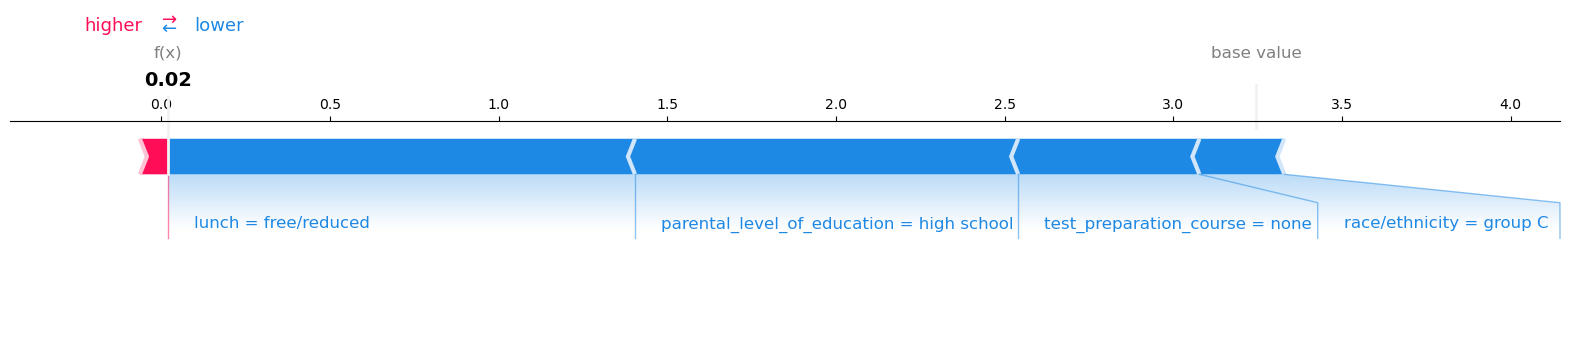

In [6]:
# --- Single prediction analysis ---
probas = model.predict_proba(X_test)[:, 1]
idx = abs(probas - 0.5).argmin()

sample = X_test.iloc[idx]

print(f"Sample index: {idx}")
print(sample)

pred = model.predict(sample.to_frame().T)[0]
proba = model.predict_proba(sample.to_frame().T)[0][1]

print("Prediction:", pred, "| probability:", round(proba, 3))

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    sample,
    matplotlib=True
)

In [ ]:
'''
For this student, the model predicts a low chance of passing. The main reasons are no test preparation, free/reduced lunch,
and lower parental education. These factors together push the prediction down.
'''

In [8]:
# pick a borderline sample (closest to decision boundary)
probas = model.predict_proba(X_test)[:, 1]
idx = abs(probas - 0.5).argmin()

sample = X_test.iloc[idx]
sample_cf = sample.copy()

# modify feature
if "test_preparation_course" in sample_cf:
    sample_cf["test_preparation_course"] = "completed"

# predictions
proba_original = model.predict_proba(sample.to_frame().T)[0][1]
proba_cf = model.predict_proba(pd.DataFrame([sample_cf]))[0][1]

pred_original = model.predict(sample.to_frame().T)[0]
pred_cf = model.predict(pd.DataFrame([sample_cf]))[0]

print(f"Sample index: {idx}")
print("\nOriginal prediction:", pred_original, "| probability:", round(proba_original, 3))
print("After change:", pred_cf, "| probability:", round(proba_cf, 3))

Sample index: 23

Original prediction: 1 | probability: 0.505
After change: 1 | probability: 0.829


In [ ]:
'''
For this sample, the model already predicts passing, but with low confidence (0.505). After changing the test preparation to completed,
the prediction stays the same, but the confidence increases to 0.829. This shows that test preparation has a strong positive effect,
even if it does not change the final decision.
'''

In [10]:
# Compare model with and without important features
# baseline
base_acc = accuracy_score(y_test, model.predict(X_test))

# remove one feature
feature = "test_preparation_course"

X_1 = X.drop(columns=[feature])

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X_1, y, test_size=0.2, random_state=42
)

cat_1 = [c for c in cat_features if c != feature]

model_1 = CatBoostClassifier(depth=5, learning_rate=0.1, iterations=200, verbose=0)
model_1.fit(X1_train, y1_train, cat_features=cat_1)

acc_1 = accuracy_score(y1_test, model_1.predict(X1_test))


# remove two features
features = ["test_preparation_course", "lunch"]

X_2 = X.drop(columns=features)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2, y, test_size=0.2, random_state=42
)

cat_2 = [c for c in cat_features if c not in features]

model_2 = CatBoostClassifier(depth=5, learning_rate=0.1, iterations=200, verbose=0)
model_2.fit(X2_train, y2_train, cat_features=cat_2)

acc_2 = accuracy_score(y2_test, model_2.predict(X2_test))


# results
print("Baseline:", round(base_acc, 3))
print("Drop (test prep):", round(base_acc - acc_1, 3))
print("Drop (test prep + lunch):", round(base_acc - acc_2, 3))

Baseline: 0.86
Drop (test prep): 0.0
Drop (test prep + lunch): 0.015


In [ ]:
'''
The results show that even though test preparation and lunch look important in the SHAP explanations, removing them does not reduce
the model accuracy much. This means that the model can use other features to make similar predictions. It also shows that feature importance
should be interpreted carefully. A feature can have a strong effect on individual predictions, but still not be critical for the overall
model performance.
'''